<a href="https://colab.research.google.com/github/polokocodes/Project-1-deployed/blob/main/Project_1_deployed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BUSINESS PROBLEM

1.THE BUSINESS PROBLEM


Loan default is among the most financially damaging risks facing lending institutions. When borrowers fail to meet repayment obligations, lenders absorb losses on outstanding principal while incurring additional costs from collections, provisioning, and regulatory compliance. The ability to identify high-risk applicants before disbursement is therefore central to sustainable credit portfolio management.

This analysis examines a dataset of 252,000 individual loan applicants across India, encompassing demographic attributes, employment history, asset ownership, profession, and geographic location. The target variable, Risk_Flag, classifies borrowers as defaulters (1) or non-defaulters (0). At an overall default rate of 12.3%, the dataset reflects a commercially realistic and class-imbalanced credit environment. The business objective is twofold: to identify which borrower characteristics are most strongly associated with default, and to establish an evidence-based foundation for a predictive credit risk model capable of improving underwriting decisions and reducing financial exposure.


2. RESEARCH QUESTIONS


The EDA was structured around seven pre-specified hypotheses to prevent retrospective cherry-picking of results. The analysis examined whether: (1) lower income predicts higher default risk; (2) younger, less experienced borrowers default more; (3) short tenure in the current job elevates risk; (4) single borrowers default more than married ones; (5) renters and non-asset-owners are more financially vulnerable; (6) profession type is associated with default; and (7) geographic location at the state level reflects differential risk. These questions span a borrower's full financial profile — from income and demographics through to employment stability, asset ownership, household structure, occupation, and region.


3. KEY INSIGHTS FROM THE EDA


The most counterintuitive finding concerned income: default rates were statistically indistinguishable across all four income quartiles, ranging from 10.3% to 12.8%.

Income alone is therefore a poor screening criterion — a result that challenges assumptions embedded in many traditional scoring models. In contrast, current job tenure emerged as the strongest numeric signal in the dataset.


Borrowers in their 1st year at a new employer defaulted at 15.6%, rising to 17.0% in their 2nd year nearly 40% above the dataset average. Risk normalises sharply after three years of tenure, reflecting the income certainty that comes with established employment.


Age and experience confirmed Hypothesis 2: the 21–30 age group defaulted at 14.5% — the highest of any cohort — while borrowers with under five years of work experience reached 14.1%. Both reflect early-career financial fragility. Housing status revealed a 40% relative gap, with homeowners defaulting at 9.0% versus 12.6% for renters, reinforcing asset ownership as a proxy for financial resilience. Marital status provided consistent signal: single borrowers defaulted at 12.5% versus 10.2% for married borrowers, consistent with dual-income households offering a buffer against repayment shocks.

Profession type produced the widest spread of any variable: Technology Specialists defaulted at 8.1% while Police Officers reached 16.4% — a near two-fold difference. High-risk professions share characteristics of irregular pay structures that introduce cash-flow volatility despite apparent employment stability. Geographic variation was equally significant, with Kerala (16.7%), Jammu and Kashmir (15.9%), and Madhya Pradesh (15.4%) leading state-level default rates, reflecting regional economic disparities not captured by individual borrower attributes alone.

#STEP 1 : Data loading and Preprocessing

In [66]:
from google.colab import files
import pandas as pd
loan_data = pd.read_csv("/content/CSEdata.csv")
loan_data.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [67]:
list(loan_data.columns)

['Id',
 'Income',
 'Age',
 'Experience',
 'Married/Single',
 'House_Ownership',
 'Car_Ownership',
 'Profession',
 'CITY',
 'STATE',
 'CURRENT_JOB_YRS',
 'CURRENT_HOUSE_YRS',
 'Risk_Flag']

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Default theme for cosistency
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8, 6)        # crisp charts
#Consistent font
plt.rcParams["font.family"] = "DejaVu Sans"
#consistent title and label size
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Color palette/dictionary used throughout
COLORS = {
    "default":     "#e05a5a",   # red   → defaulters
    "no_default":  "#69d99f",   # green → non-defaulters
    "amber":       "#f0a500",   # orange → warning / middle ground
    "blue":        "#4fc3f7",   # blue  → neutral
    "muted":       "#7a8099",   # grey  → secondary info
}


In [69]:
# Number of columns(252000) and rows(13)
print("Shape:", loan_data.shape)
#List of features and target
print("\nColumns:\n", loan_data.columns.tolist())
#The number of missing values in the data
print("\nMissing values:\n", loan_data.isnull().sum())
#Data type check
print("\nData types:\n", loan_data.dtypes)
#Counts the number of defaulters and non defaulters
print("\nTarget distribution:\n", loan_data["Risk_Flag"].value_counts())
#Changes the binary of Risk flag into percentages to be easily understood
print("\nDefault rate: {:.1%}".format(loan_data["Risk_Flag"].mean()))



Shape: (252000, 13)

Columns:
 ['Id', 'Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag']

Missing values:
 Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

Data types:
 Id                    int64
Income                int64
Age                   int64
Experience            int64
Married/Single       object
House_Ownership      object
Car_Ownership        object
Profession           object
CITY                 object
STATE                object
CURRENT_JOB_YRS       int64
CURRENT_HOUSE_YRS     int64
Risk_Flag             int64
dtype: object

Target distribution:
 Risk_Flag
0    221004
1     30996
Name: count, d

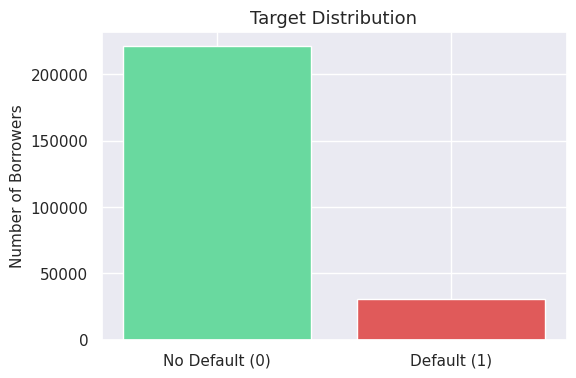

Default rate: 12.3%


In [70]:
# Check class counts
counts = loan_data["Risk_Flag"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    ["No Default (0)", "Default (1)"],
    counts.values,
    color=[COLORS["no_default"], COLORS["default"]]
)

plt.title("Target Distribution")
plt.ylabel("Number of Borrowers")

# Add numbers on top
#for i, v in enumerate(counts.values):
    #plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.show()

print("Default rate: {:.1%}".format(loan_data["Risk_Flag"].mean()))

#Hypothesis 1:Is income is a good indicator for defaulting

/tmp/ipykernel_342/2870286462.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = loan_data.groupby("income_group")["Risk_Flag"].mean().reset_index()
/tmp/ipykernel_342/2870286462.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="income_group",y="default_pct",data=income_default,palette=bar_colors)


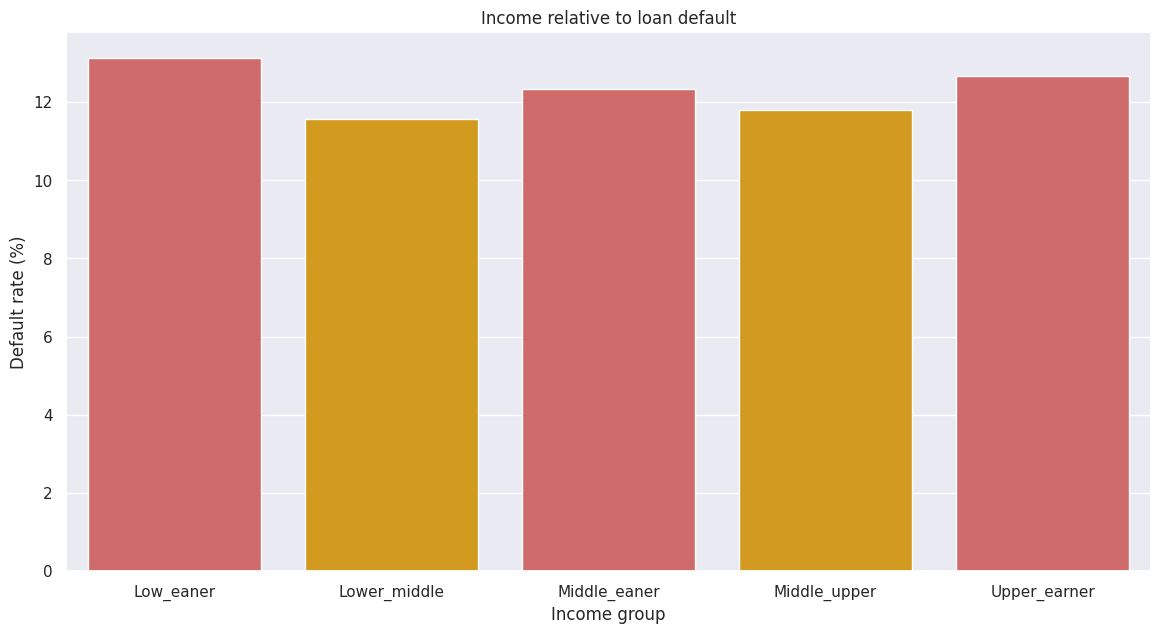

In [71]:
sns.set_theme(style="darkgrid")
# Create the income labels
income_labels = [
    "Low_eaner",
    "Lower_middle",
    "Middle_eaner",
    "Middle_upper",
    "Upper_earner"
    ]

#Create the new income group column
loan_data["income_group"] = pd.qcut(loan_data['Income'],q=5,labels=income_labels)

#Calculate default rate per income group(percentage)
income_default = loan_data.groupby("income_group")["Risk_Flag"].mean().reset_index()

income_default["default_pct"]= income_default["Risk_Flag"]*100

#Color scheme
bar_colors = []
for r in income_default["default_pct"]:
    if r > 12:
        bar_colors.append(COLORS["default"])
    else:
        bar_colors.append(COLORS["amber"])

#plot the graph
plt.figure(figsize=(14,7))
plt.title("Income relative to loan default")

sns.barplot(x="income_group",y="default_pct",data=income_default,palette=bar_colors)
plt.xlabel("Income group")
plt.ylabel("Default rate (%)")
plt.show()




My final findings are, income is a weak predictor of defaulting because the default rate across the data is identical

#Hypothesis 2 - Does Age have an effect on default rate

/tmp/ipykernel_342/3198014732.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = loan_data.groupby("age_group")["Risk_Flag"].mean().reset_index()
/tmp/ipykernel_342/3198014732.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="age_group",y="default_pct",data=age_default,palette=bar_colors)


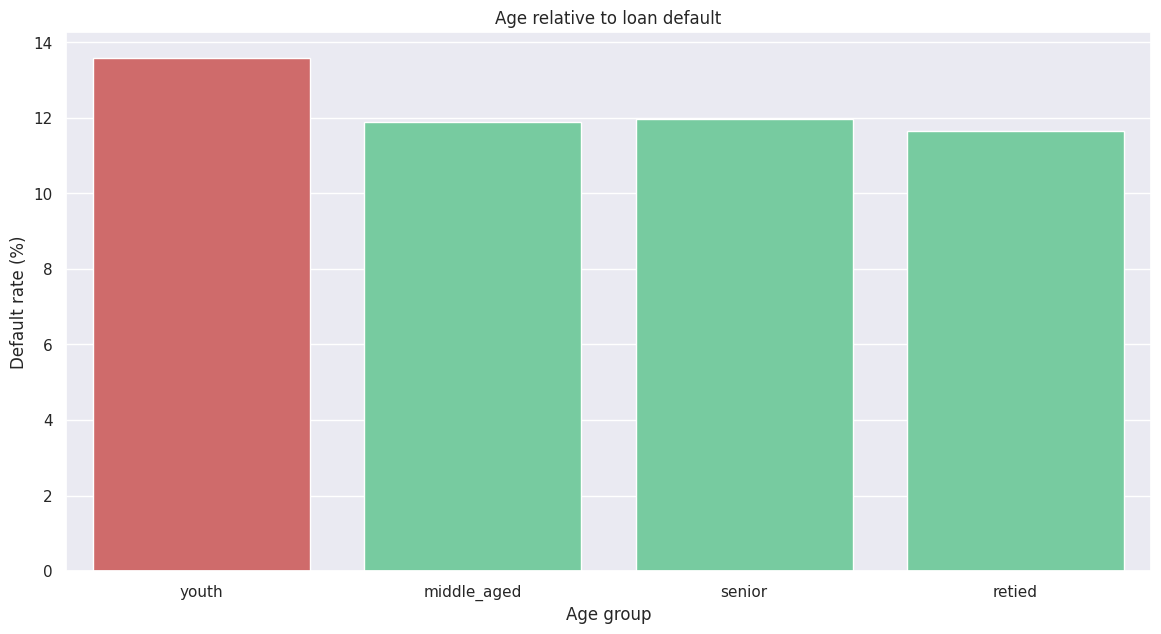

In [72]:
#--------------------------------------------------

#--------------------------------------------------

#Create age labels
age_labels = ["youth","middle_aged","senior","retied"]

#Create an age group column
loan_data["age_group"] = pd.qcut(loan_data['Age'],q=4,labels=age_labels)

#Change defualt data from binary into percentages
#Create the age_default variable
age_default = loan_data.groupby("age_group")["Risk_Flag"].mean().reset_index()
#create the default percentages
age_default["default_pct"] = age_default["Risk_Flag"]*100

#Color scheme
bar_colors = []
for r in age_default["default_pct"]:
    if r > 12:
        bar_colors.append(COLORS["default"])
    elif r == 12:
        bar_colors.append(COLORS["amber"])
    else:
        bar_colors.append(COLORS["no_default"])

#plot the graph
plt.figure(figsize=(14,7))
plt.title("Age relative to loan default")

sns.barplot(x="age_group",y="default_pct",data=age_default,palette=bar_colors)
plt.xlabel("Age group")
plt.ylabel("Default rate (%)")
plt.show()


From the graph it can be pointed out that the youth are the riskiest of the groups and will likely default. Age comes out as a good indicator of default risk.

#Hypothesis 3: Is Experience a good indicator for defaulting

/tmp/ipykernel_342/3461076658.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_level_default = loan_data.groupby("exp_level_group")['Risk_Flag'].mean().reset_index()
/tmp/ipykernel_342/3461076658.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="exp_level_group",y="default_pct",data=exp_level_default,palette=bar_colors)


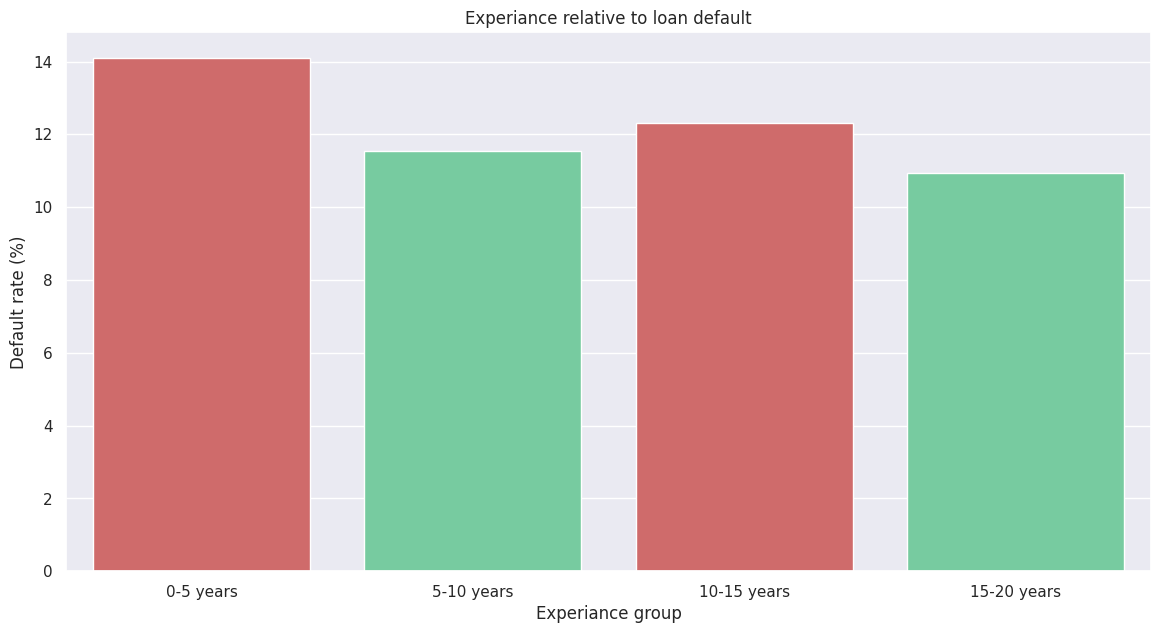

In [73]:
#Create the experiance labels
exp_labels = ["0-5 years","5-10 years","10-15 years","15-20 years"]

#Create the exp_level_group column
loan_data["exp_level_group"] = pd.qcut(loan_data['Experience'],q=4,labels=exp_labels)

#Change the risk data from binary to percentages
#Create the exp_level_default variable
exp_level_default = loan_data.groupby("exp_level_group")['Risk_Flag'].mean().reset_index()

#Create the default percentage column
exp_level_default["default_pct"] = exp_level_default["Risk_Flag"]*100

#Color scheme
bar_colors = []
for r in exp_level_default["default_pct"]:
    if r > 12:
        bar_colors.append(COLORS["default"])
    elif r == 12:
        bar_colors.append(COLORS["amber"])
    else:
        bar_colors.append(COLORS["no_default"])

#plot the graph
plt.figure(figsize=(14,7))
plt.title("Experiance relative to loan default")

sns.barplot(x="exp_level_group",y="default_pct",data=exp_level_default,palette=bar_colors)
plt.xlabel("Experiance group")
plt.ylabel("Default rate (%)")
plt.show()




Findings: What is visible from the graph is that people with less experiance are more likely to default and as experiance increases the more default risk decreases. This indicates that experiance is a good indicator for default risk.

#Hypothesis 4:Marital status is a good indicator for risk of defaulting

/tmp/ipykernel_342/3745518580.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Married/Single",y="default_pct",data=marital_default,palette=bar_colors)


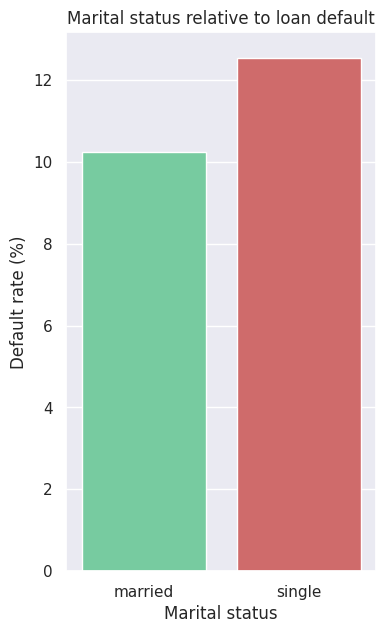

In [74]:
#Change the risk data from binary to percentages
#Create the marital_default variable
marital_default = loan_data.groupby("Married/Single")['Risk_Flag'].mean().reset_index()

#Create the default percentage column
marital_default["default_pct"] = marital_default["Risk_Flag"]*100

#Color scheme
bar_colors = []
for r in marital_default["default_pct"]:
    if r > 12:
        bar_colors.append(COLORS["default"])
    else:
        bar_colors.append(COLORS["no_default"])

#plot the graph
plt.figure(figsize=(4,7))
plt.title("Marital status relative to loan default")

sns.barplot(x="Married/Single",y="default_pct",data=marital_default,palette=bar_colors)
plt.xlabel("Marital status")
plt.ylabel("Default rate (%)")
plt.show()

Findings:Marital status is a good indicator for default risk as we can see single people are more likely to default than married people.

#Hypothesis 5: Home ownership is a good indicator for default risk/ Is home ownership a good indicator

/tmp/ipykernel_342/4182311839.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='House_Ownership',y='default_pct',data =hm_own_default,palette = bar_colors )


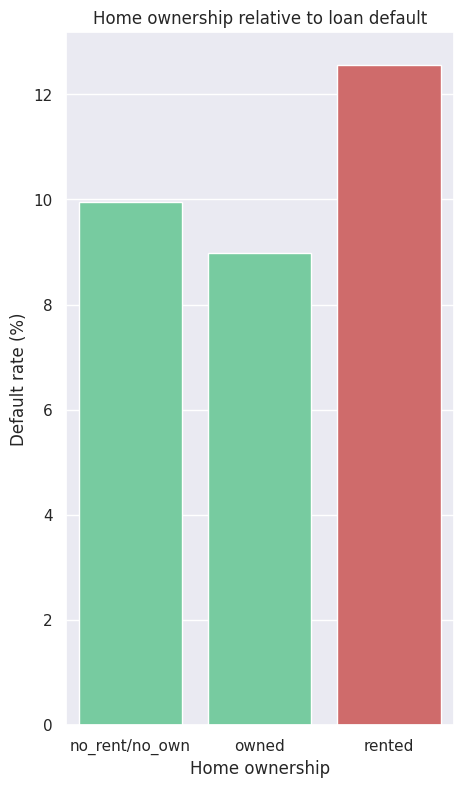

In [75]:
loan_data['House_Ownership'] = loan_data['House_Ownership'].replace('norent_noown', 'no_rent/no_own')
#create the house ownership default variable
hm_own_default = loan_data.groupby("House_Ownership")["Risk_Flag"].mean().reset_index()

hm_own_default["default_pct"] = hm_own_default["Risk_Flag"]*100

#Color scheme
bar_colors = []
for r in hm_own_default["default_pct"]:
    if r > 12:
        bar_colors.append(COLORS["default"])
    elif r == 12:
        bar_colors.append(COLORS["amber"])
    else:
        bar_colors.append(COLORS["no_default"])

plt.figure(figsize=(5,9))
plt.title("Home ownership relative to loan default")
sns.barplot(x='House_Ownership',y='default_pct',data =hm_own_default,palette = bar_colors )
x_label = plt.xlabel("Home ownership")
y_label = plt.ylabel("Default rate (%)")
plt.show()


Findings: It is evident that people who are renting are more likely to default on the loans more than people who own their houses.

#Hypothesis 6: Car ownership is a good indicator for default risk

/tmp/ipykernel_342/2884462798.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Car_Ownership',y='default_pct',data =car_own_default,palette = bar_colors )


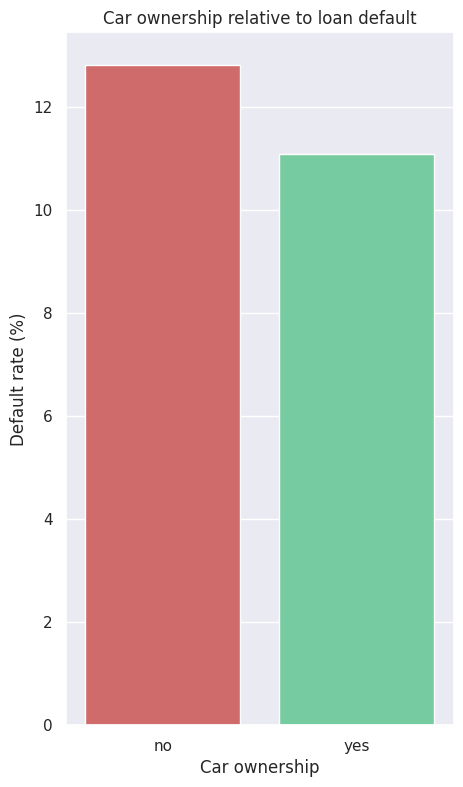

In [76]:
#------------------------------------------------------------------------
# Car ownership
#------------------------------------------------------------------------

#Create the default car ownership variable
car_own_default = loan_data.groupby('Car_Ownership')['Risk_Flag'].mean().reset_index()

#Convert the risk flag binary to percentage
car_own_default['default_pct'] = car_own_default['Risk_Flag']*100

#Color scheme
bar_colors = []
for r in car_own_default["default_pct"]:
    if r > 12:
        bar_colors.append(COLORS["default"])

    else:
        bar_colors.append(COLORS["no_default"])


plt.figure(figsize=(5,9))
plt.title("Car ownership relative to loan default")
sns.barplot(x='Car_Ownership',y='default_pct',data =car_own_default,palette = bar_colors )
x_label = plt.xlabel("Car ownership")
y_label = plt.ylabel("Default rate (%)")
plt.show()

Findings: People with no cars are more likely to default on their loans than people who own.

#Hypothesis 7: Profession is a good indicator for default risk

/tmp/ipykernel_342/3835489464.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profession', y='default_pct', data=prof_default, palette=bar_colors)


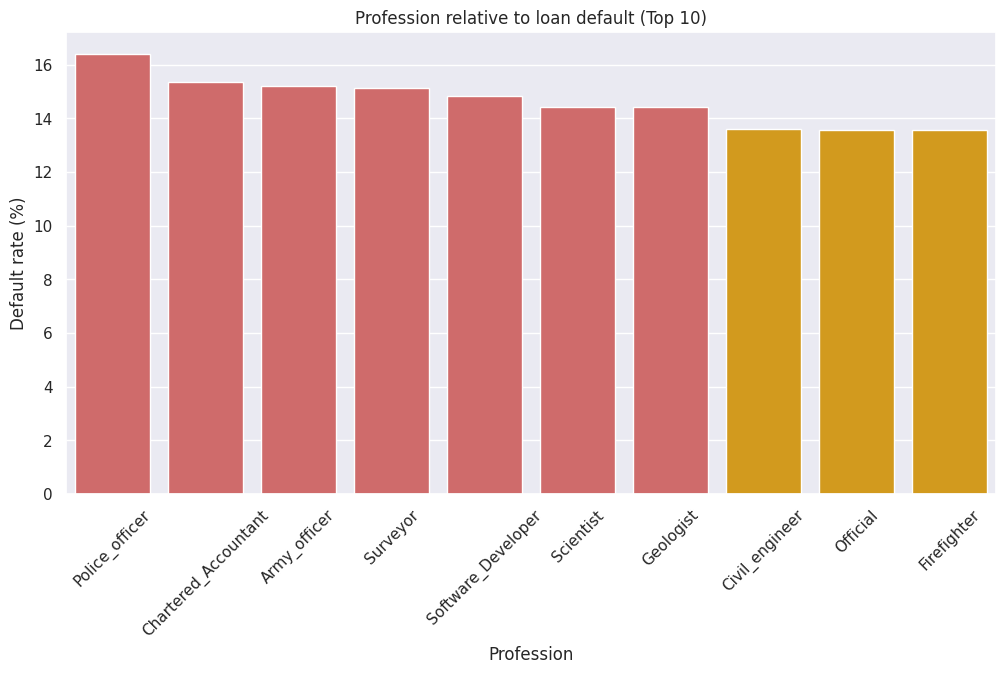

In [77]:
# Create the default profession variable (Top 10 for readability)
prof_default = loan_data.groupby('Profession')['Risk_Flag'].mean().reset_index()

# Convert the risk flag binary to percentage/top professions
prof_default['default_pct'] = prof_default['Risk_Flag'] * 100
prof_default = prof_default.sort_values("default_pct", ascending=False).head(10)


# Color scheme
bar_colors = []
for r in prof_default["default_pct"]:
    if r > 14:
        bar_colors.append(COLORS["default"])

    elif r > 12:
        bar_colors.append(COLORS["amber"])
    else:
        bar_colors.append(COLORS["no_default"])

#Charts for the top professions
plt.figure(figsize=(12, 6))
plt.title("Profession relative to loan default (Top 10)")
sns.barplot(x='Profession', y='default_pct', data=prof_default, palette=bar_colors)
plt.xticks(rotation=45)
plt.xlabel("Profession")
plt.ylabel("Default rate (%)")
plt.show()


/tmp/ipykernel_342/435237510.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profession', y='default_pct', data=prof_bottom, palette=bar_colors)


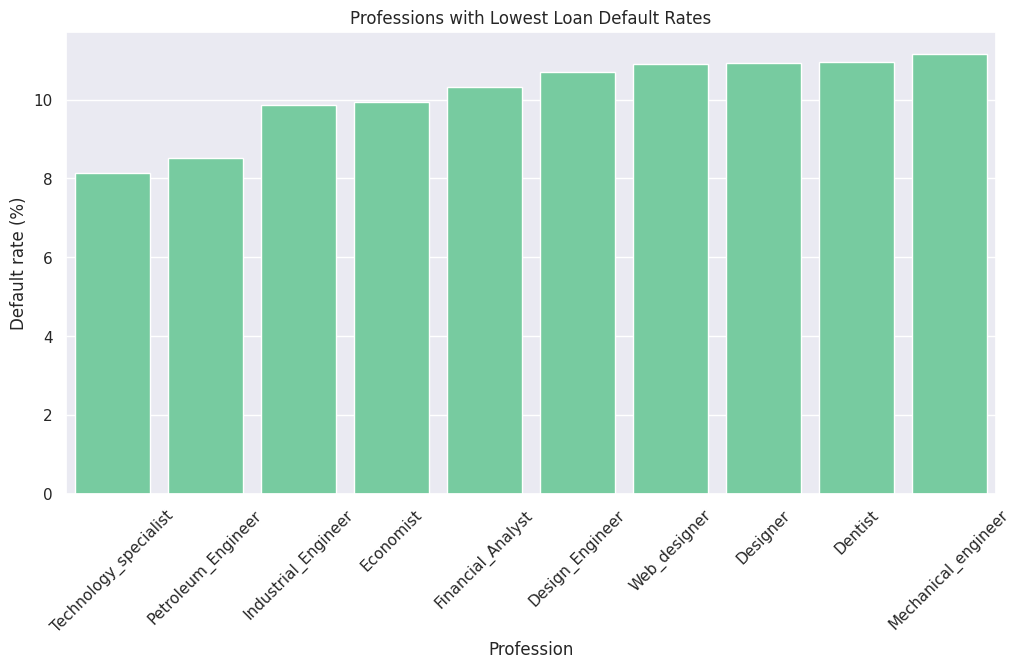

In [78]:
#------------------------------------------------------------------------
# Lowest Risk Professions
#------------------------------------------------------------------------

# Create the default profession variable
prof_default = loan_data.groupby('Profession')['Risk_Flag'].mean().reset_index()

# Convert the risk flag binary to percentage
prof_default['default_pct'] = prof_default['Risk_Flag'] * 100

# CHANGE: Sort ascending=True to get the lowest default rates at the top
prof_bottom = prof_default.sort_values("default_pct", ascending=True).head(10)

# Color scheme (using "no_default" since these are low risk)
bar_colors = []
for r in prof_bottom["default_pct"]:
    if r > 12:
        bar_colors.append(COLORS["default"])
    else:
        bar_colors.append(COLORS["no_default"])

plt.figure(figsize=(12, 6))
plt.title("Professions with Lowest Loan Default Rates")
sns.barplot(x='Profession', y='default_pct', data=prof_bottom, palette=bar_colors)
plt.xticks(rotation=45)
plt.xlabel("Profession")
plt.ylabel("Default rate (%)")
plt.show()

The findings are professions are a very good indicator of default risk as professions with low pay like police officers and firefighters  are more likely to default

#Hypothesis 8: Is geography a good indicator for default risk

/tmp/ipykernel_342/1580847166.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='STATE', y='default_pct', data=state_default, palette=bar_colors)


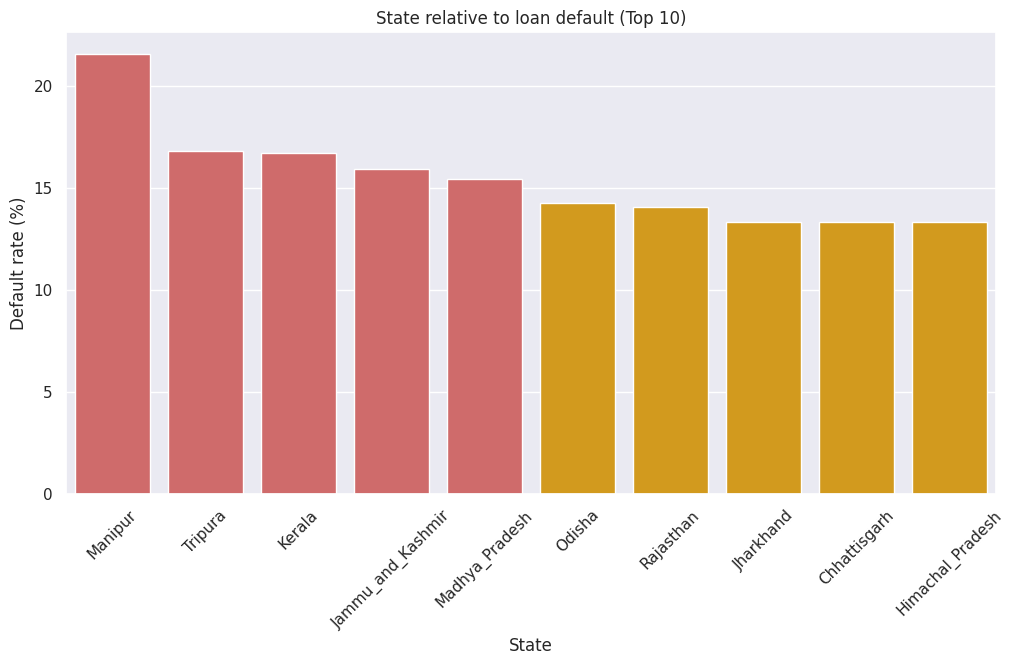

In [79]:
# Create the default state variable
state_default = loan_data.groupby('STATE')['Risk_Flag'].mean().reset_index()

# Convert the risk flag binary to percentage
state_default['default_pct'] = state_default['Risk_Flag'] * 100
state_default = state_default.sort_values("default_pct", ascending=False).head(10)

# Color scheme
bar_colors = []
for r in state_default["default_pct"]:
    if r >= 15:
        bar_colors.append(COLORS["default"])

    elif r >= 12:
        bar_colors.append(COLORS["amber"])

    else:
        bar_colors.append(COLORS["blue"])

plt.figure(figsize=(12, 6))
plt.title("State relative to loan default (Top 10)")
sns.barplot(x='STATE', y='default_pct', data=state_default, palette=bar_colors)
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Default rate (%)")
plt.show()

Findings:Geographic variation is significant, with Kerala (16.7%), Jammu and Kashmir (15.9%), and Madhya Pradesh (15.4%) leading state-level default rates, reflecting regional economic disparities not captured by individual borrower attributes alone.

In [80]:
#------------------------------------------------------------------------
# Correlation Heatmap
#------------------------------------------------------------------------

# Select only numeric columns
#numeric_cols = ["Income", "Age", "Experience", "CURRENT_JOB_YRS", "CURRENT_HOUSE_YRS", "Risk_Flag"]
#corr_matrix = loan_data[numeric_cols].corr()

#plt.figure(figsize=(10, 8))
#plt.title("Correlation Heatmap of Numeric Features")
#sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
#plt.show()

#STEP 2:Clean the Data

In [81]:
#Drop low value columns
col_to_drop = ["Id","CITY","CURRENT_HOUSE_YRS"]
# Filter out columns that don't exist before attempting to drop
existing_cols_to_drop = [col for col in col_to_drop if col in loan_data.columns]
if existing_cols_to_drop:
    loan_data = loan_data.drop(columns=existing_cols_to_drop)

#Encode Categorical Variables
#Label encoding for married/single column
# Check if the column exists
if 'Married/Single' in loan_data.columns and loan_data['Married/Single'].dtype == 'object':
    loan_data['Married/Single'] = loan_data['Married/Single'].map({'married':0,'single':1})

#Car ownership
# Check if the column exists and if it's still an object type
if 'Car_Ownership' in loan_data.columns and loan_data['Car_Ownership'].dtype == 'object':
    loan_data['Car_Ownership'] = loan_data['Car_Ownership'].map({'no':0,'yes':1})

#One-hot encoding for house ownership
# Check if the 'House_Ownership' column exists and is an object type
if 'House_Ownership' in loan_data.columns and loan_data['House_Ownership'].dtype == 'object':
    # 'norent_noown' is replaced before one-hot encoding if it wasn't done for the current loan_data
    loan_data['House_Ownership'] = loan_data['House_Ownership'].replace('norent_noown', 'no_rent/no_own')
    loan_data = pd.get_dummies(loan_data, columns=['House_Ownership'], prefix='house', drop_first=True)

# Target Encoding: Profession and State

# 1. Encode Profession
prof_means = loan_data.groupby('Profession')['Risk_Flag'].mean()
loan_data['profession_encoded'] = loan_data['Profession'].map(prof_means)

# 2. Encode STATE
state_means = loan_data.groupby('STATE')['Risk_Flag'].mean()
loan_data['state_encoded'] = loan_data['STATE'].map(state_means)

# 3. Drop the original text columns to clean up
loan_data = loan_data.drop(columns=['Profession', 'STATE'])

print("Encoded columns 'profession_encoded' and 'state_encoded' created.")

# Verify the new columns
print("New house encoding columns:", [c for c in loan_data.columns if 'house' in c])

Encoded columns 'profession_encoded' and 'state_encoded' created.
New house encoding columns: ['house_owned', 'house_rented']


In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(loan_data["profession_encoded"])
print(list(le.classes_))  # shows all profession names in order

[np.float64(0.08148617268313278), np.float64(0.08510216226939099), np.float64(0.09866666666666667), np.float64(0.09927837305926088), np.float64(0.10315463518482679), np.float64(0.1069993656164094), np.float64(0.10913470446544377), np.float64(0.10917790343627665), np.float64(0.109577582601422), np.float64(0.11155836687751582), np.float64(0.11162343900096061), np.float64(0.11225728155339806), np.float64(0.11257562662057044), np.float64(0.1128941966784848), np.float64(0.11536972512582269), np.float64(0.11538461538461539), np.float64(0.11546521374685666), np.float64(0.11557009989665863), np.float64(0.11579424427826875), np.float64(0.11808300395256917), np.float64(0.11918751049185831), np.float64(0.11960448754516068), np.float64(0.12002986746313235), np.float64(0.12146529562982006), np.float64(0.12146709816612729), np.float64(0.12189239332096476), np.float64(0.1226085167660975), np.float64(0.12363494539781592), np.float64(0.12404809619238477), np.float64(0.12435976234378202), np.float64(0.1

In [83]:
#Target variable
y = loan_data["Risk_Flag"]

#Features
features = ['Age', 'Experience','Married/Single','house_rented','Car_Ownership','state_encoded','profession_encoded', 'CURRENT_JOB_YRS']

X = pd.get_dummies(loan_data[features])



#STEP 3:Develop machine learning model

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split the training data for local validation (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("\nData Split Complete:")
print(f"X_train (80% for training model): {X_train.shape}")
print(f"X_val (20% for local testing/validation): {X_val.shape}")


Data Split Complete:
X_train (80% for training model): (201600, 8)
X_val (20% for local testing/validation): (50400, 8)


In [85]:
#Train the model
model = LogisticRegression()
#Fit the model
model.fit(X_train,y_train)

#prediction
y_pred = model.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#STEP 4:Evaluate performance of the logistic regression model

In [86]:
model_accuracy = accuracy_score(y_val,y_pred)
print(f"Model Accuracy: {model_accuracy}")

Model Accuracy: 0.8759325396825397


#STEP 5:Save the model

In [87]:
import joblib

joblib.dump(model, "loan_data_model.pkl")

['loan_data_model.pkl']

This creates a portable model file used by the web application.

#STEP 6:Download the model from colab

In [88]:
from google.colab import files
files.download("loan_data_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#STEP 7: Build the streamlit app

In [89]:
!pip install streamlit

In [90]:
#We have not yet created the py file rather we just designed the flow of its contents, there is an additional step proceeding
import streamlit as st
import joblib
import numpy as np

model = joblib.load("loan_data_model.pkl")

st.title("Loan default prediction")

age = st.number_input("Age")
experiance = st.number_input("Experience")
current_job_years = st.number_input("Years in current job")
profession_label = st.selectbox(
    "Select your profession",
    options=list(prof_means.index),  # profession names
    index=None,
    placeholder="Type to search..."
)

if profession_label:
    profession_encoded = prof_means[profession_label]

state_label = st.selectbox(
    "Select your state",
    options=list(state_means.index),  # state names
    index=None,
    placeholder="Type to search..."
)
if state_label:
    state_encoded = state_means[state_label]


Car_Ownership = st.selectbox("Car ownership", ["yes","no"])
marriedSingle = st.selectbox("Married/Single", ["married","single"])
house_rented = st.selectbox("House rented", ["yes","no"])

if st.button("Predict Loan Default"):

    features = np.array([[age,experiance,current_job_years,profession_label,state_label,
                          1 if marriedSingle=="married" else 0,
                          1 if Car_Ownership=="yes" else 0,
                          1 if house_rented=="yes" else 0,
                          ]])

    prediction = model.predict(features)

    st.success(f"Estimated Loan default: {prediction[0]}")

2026-03-07 23:07:09.663 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 23:07:09.665 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 23:07:09.666 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 23:07:09.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 23:07:09.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 23:07:09.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 23:07:09.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 23:07:09.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [91]:
code = '''
import streamlit as st
import joblib
import numpy as np

model = joblib.load("loan_data_model.pkl")

st.title("Loan default prediction")

age = st.number_input("Age")
experiance = st.number_input("Experience")
current_job_years = st.number_input("Years in current job")
profession_label = st.selectbox(
    "Select your profession",
    options=list(prof_means.index),  # profession names
    index=None,
    placeholder="Type to search..."
)

if profession_label:
    profession_encoded = prof_means[profession_label]

state_label = st.selectbox(
    "Select your state",
    options=list(state_means.index),  # state names
    index=None,
    placeholder="Type to search..."
)
if state_label:
    state_encoded = state_means[state_label]


Car_Ownership = st.selectbox("Car ownership", ["yes","no"])
marriedSingle = st.selectbox("Married/Single", ["married","single"])
house_rented = st.selectbox("House rented", ["yes","no"])

if st.button("Predict Loan Default"):

    features = np.array([[age,experiance,current_job_years,profession_label,state_label,
                          1 if marriedSingle=="married" else 0,
                          1 if Car_Ownership=="yes" else 0,
                          1 if house_rented=="yes" else 0,
                          ]])

    prediction = model.predict(features)

    st.success(f"Estimated Loan default: {prediction[0]}")
    '''
with open("app.py", "w") as f:
    f.write(code)

In [92]:
#Create requirements text file
#streamlit
#scikit-learn
#pandas
#numpy
#joblib
with open("requirements.txt", "w") as f:
  f.write("streamlit\nnumpy\nscikit-learn\njoblib")